In [ ]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import os
for dirname, _, filenames in os.walk('./data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/gpus-specs-from-1986-to-2026/gpu_1986-2026.csv


In [ ]:


df = pd.read_csv("./data/gpus-specs-from-1986-to-2026/gpu_1986-2026.csv")

In [3]:
def clean_and_convert_numeric(value_str):
    if pd.isna(value_str) or 'unknown' in str(value_str).lower():
        return np.nan
        
    s = str(value_str).strip()
    multiplier = 1.0

    if 'B' in s.upper(): # Billion
        multiplier = 1e9
        s = re.sub(r'[B|b]illion', '', s)
    elif 'M' in s.upper(): # Million
        multiplier = 1e6
        s = re.sub(r'[M|m]illion', '', s)
    elif 'k' in s.lower(): # Thousand
        multiplier = 1e3
        s = re.sub(r'[k]ilo', '', s)
        
    # FIX: Use re.sub to remove all remaining non-numeric characters (except dot)
    cleaned_value = re.sub(r'[^\d\.]', '', s)

    try:
        if cleaned_value:
            return float(cleaned_value) * multiplier
    except ValueError:
        pass

    return np.nan 


def convert_to_mb(size_str):
    if pd.isna(size_str):
        return np.nan
    
    size_str = str(size_str).strip().upper().replace(',', '')
    
    try:
        if 'KB' in size_str:
            value = size_str.replace('KB', '').strip()
            return float(value) / 1024  # KB to MB
        elif 'MB' in size_str:
            value = size_str.replace('MB', '').strip()
            return float(value)  # MB to MB (The previous crash site)
        elif 'GB' in size_str:
            value = size_str.replace('GB', '').strip()
            return float(value) * 1024  # GB to MB
        elif 'TB' in size_str:
            value = size_str.replace('TB', '').strip()
            return float(value) * 1024 * 1024  # TB to MB
        
        # Catch raw numbers 
        return float(size_str)
        
    except ValueError:
        return np.nan


def extract_year(date_str):
    if pd.isna(date_str) or str(date_str).strip() == '':
        return np.nan
        
    s = str(date_str).strip()

    s_cleaned = re.sub(r'(\s+\d+(th|st|nd|rd|,))', ' ', s)

    try:
        year = pd.to_datetime(s_cleaned, errors='coerce').year
        if not pd.isna(year):
            return year
    except:
        pass
        
    try:
        match = re.search(r'(\d{4})', s)
        if match:
            year = int(match.group(1))
            if 1980 <= year <= 2030:
                return year
    except:
        pass

    return np.nan

def clean_and_convert_numeric_fixed(value_str):
    """Aggressively cleans strings of non-digit/non-decimal characters and handles B/M/k units."""
    if pd.isna(value_str) or 'unknown' in str(value_str).lower():
        return np.nan
        
    s = str(value_str).strip()
    multiplier = 1.0


    if 'B' in s.upper():
        multiplier = 1e9
    elif 'M' in s.upper():
        multiplier = 1e6
        
    
    s = re.sub(r'[A-Za-z]', '', s)
    cleaned_value = re.sub(r'[^\d\.]', '', s) 
    try:
        if cleaned_value:
            return float(cleaned_value) * multiplier
    except ValueError:
        pass
    return np.nan
    





In [4]:
threshold = 0.50 * len(df)
initial_columns = df.shape[1]
df_cleaned = df.dropna(thresh=threshold, axis=1)
columns_dropped = initial_columns - df_cleaned.shape[1]


    
df['Release_Year'] = df['Graphics Card__Release Date'].apply(extract_year).astype('Int64')
df['Transistors_Count'] = df['Graphics Processor__Transistors'].apply(clean_and_convert_numeric) 
df['Process_Size_NM'] = df['Graphics Processor__Process Size'].apply(clean_and_convert_numeric)
df['GPU_Clock'] = df['Clock Speeds__GPU Clock'].apply(clean_and_convert_numeric_fixed)
df['Memory_MB'] = df['Top__MEMORY SIZE'].apply(convert_to_mb)
df['Release_Date_Cleaned'] = df['Graphics Card__Release Date'].str.replace(r'(\s+\d+(th|st|nd|rd|,))', '', regex=True)
df['Release_Year'] = pd.to_datetime(df['Release_Date_Cleaned'], errors='coerce').dt.year


df_plot = df.dropna(subset=['Release_Year', 'Memory_MB']).copy()
df_plot['Release_Year'] = df_plot['Release_Year'].astype(int)

/tmp/ipykernel_13/1461721833.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Release_Year'] = pd.to_datetime(df['Release_Date_Cleaned'], errors='coerce').dt.year


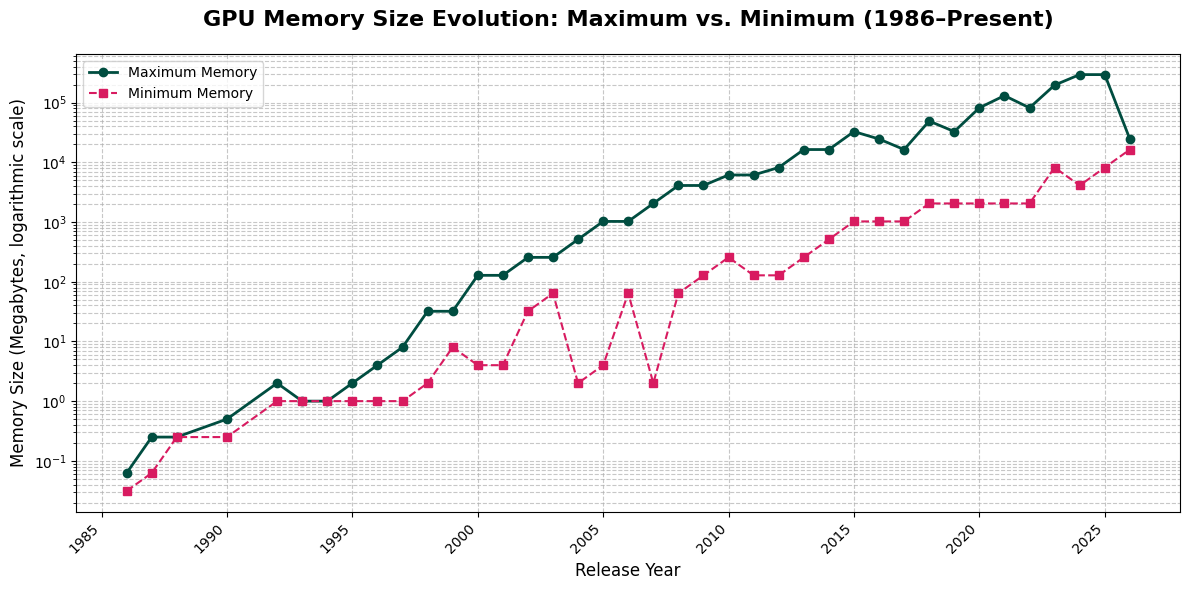

In [5]:

df_plot = df.dropna(subset=['Release_Year', 'Memory_MB']).copy()
df_plot['Release_Year'] = df_plot['Release_Year'].astype(int)

memory_envelopes = df_plot.groupby('Release_Year')['Memory_MB'].agg(['max', 'min']).reset_index()

plt.figure(figsize=(12, 6))

plt.plot(memory_envelopes['Release_Year'], memory_envelopes['max'], 
         label='Maximum Memory', marker='o', linestyle='-', color='#004D40', linewidth=2)

plt.plot(memory_envelopes['Release_Year'], memory_envelopes['min'], 
         label='Minimum Memory', marker='s', linestyle='--', color='#D81B60', linewidth=1.5)

plt.yscale('log')

plt.title('GPU Memory Size Evolution: Maximum vs. Minimum (1986–Present)', fontsize=16, pad=20, weight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Memory Size (Megabytes, logarithmic scale)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show() 

<Figure size 1400x700 with 0 Axes>

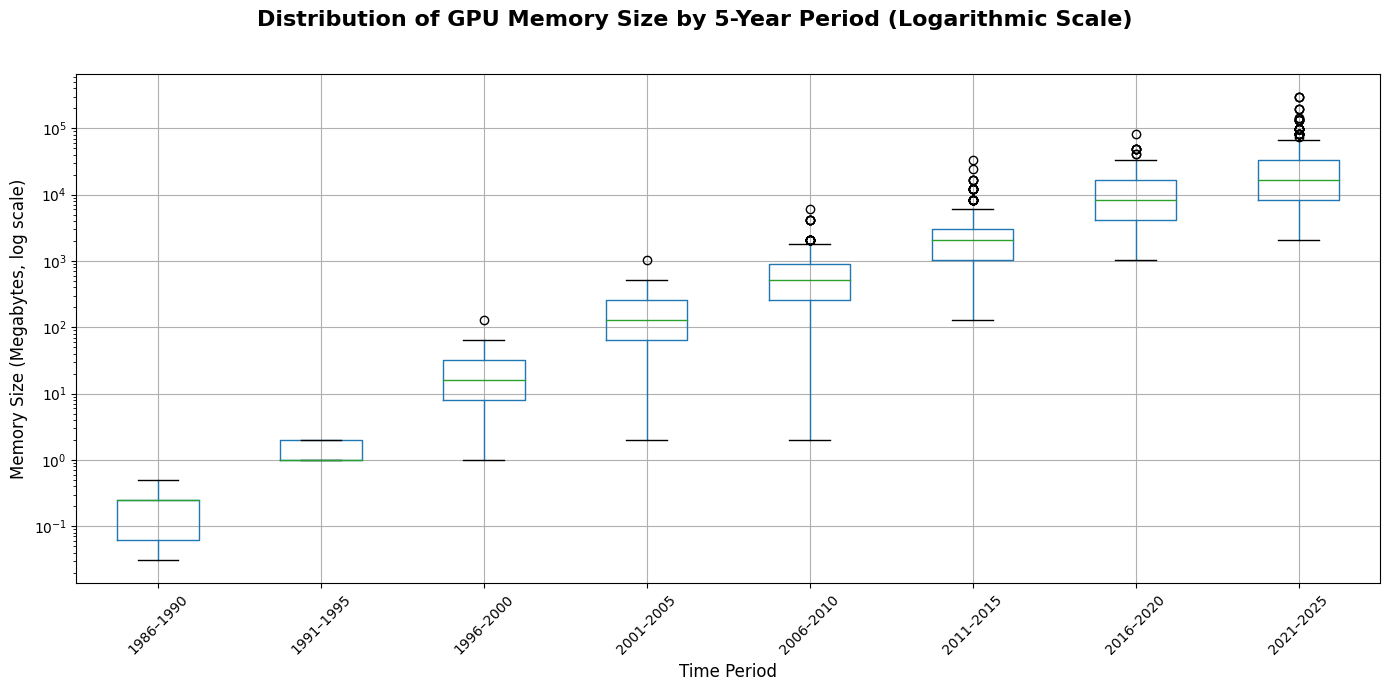

In [6]:
min_year = df_plot['Release_Year'].min()
max_year = df_plot['Release_Year'].max()

bins = np.arange(min_year, max_year + 5, 5)
labels = [f'{i}–{i+4}' for i in bins[:-1]]


df_plot['Time_Period'] = pd.cut(
    df_plot['Release_Year'], 
    bins=bins, 
    labels=labels, 
    right=False,
    include_lowest=True
)


plt.figure(figsize=(14, 7))
df_plot.boxplot(column='Memory_MB', by='Time_Period', grid=True, rot=45, figsize=(14, 7))


plt.suptitle('Distribution of GPU Memory Size by 5-Year Period (Logarithmic Scale)', fontsize=16, weight='bold')
plt.title('') 
plt.yscale('log') 

plt.xlabel('Time Period', fontsize=12)
plt.ylabel('Memory Size (Megabytes, log scale)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 


plt.savefig('gpu_memory_boxplot_distribution.png')
# plt.show()

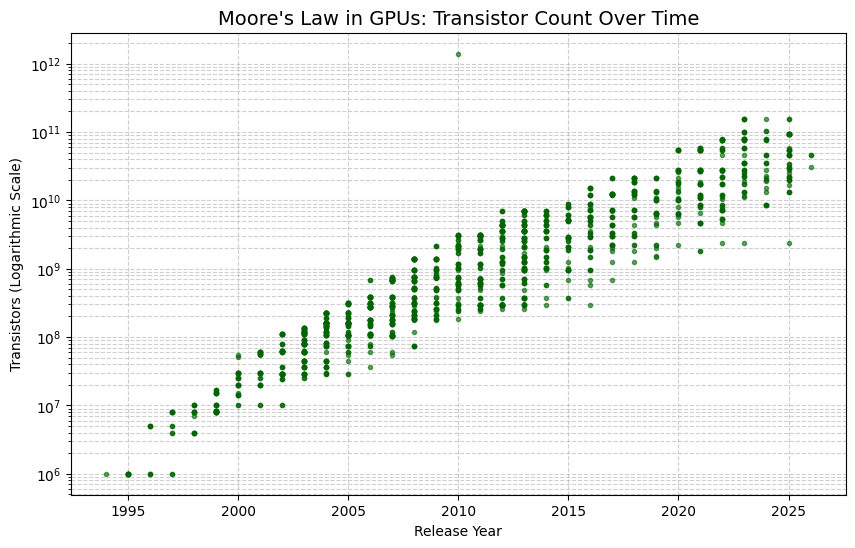

In [7]:
df_cleaned = df[df['Release_Year'].notna()].copy()
df_trans = df_cleaned.dropna(subset=['Transistors_Count']).sort_values('Release_Year')


plt.figure(figsize=(10, 6))
plt.plot(df_trans['Release_Year'], df_trans['Transistors_Count'], marker='.', linestyle='', alpha=0.6, color='darkgreen')
plt.yscale('log')
plt.title('Moore\'s Law in GPUs: Transistor Count Over Time', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Transistors (Logarithmic Scale)')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()

/tmp/ipykernel_13/2700056319.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_perf = df_cleaned.fillna(0)
/tmp/ipykernel_13/2700056319.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_perf['Performance_Score'] = (
/tmp/ipykernel_13/2700056319.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_p

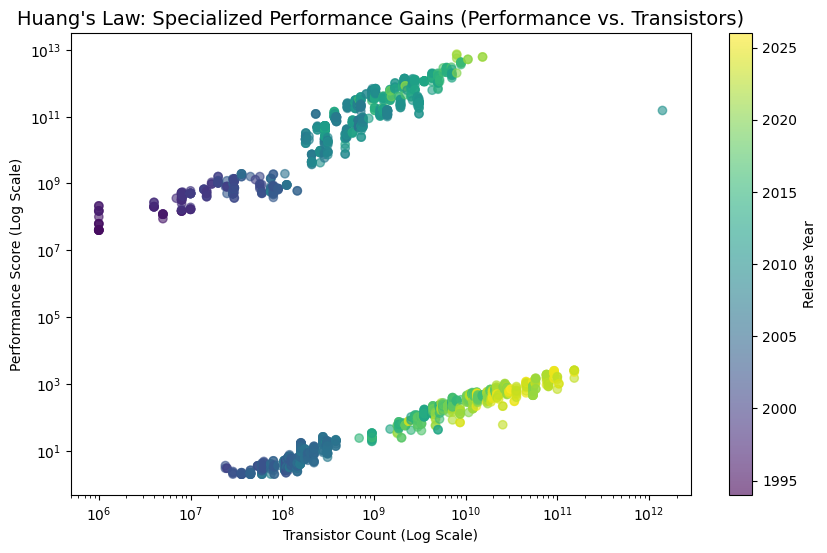

In [8]:
numeric_cols = [
    'Theoretical Performance__Texture Rate', 'Theoretical Performance__Pixel Rate', 
    'Board Design__TDP', 'Render Config__Shading Units', 'Clock Speeds__GPU Clock', 
    'Graphics Card__Launch Price'
]
for col in numeric_cols:
    new_col_name = col.replace('__', '_CLEAN_')
    df[new_col_name] = df[col].apply(clean_and_convert_numeric)

df_cleaned = df[df['Release_Year'].notna()].copy()

df_perf = df_cleaned.fillna(0) 
df_perf['Performance_Score'] = (
    df_perf['Render Config_CLEAN_Shading Units'] * df_perf['Clock Speeds_CLEAN_GPU Clock']
    + df_perf['Theoretical Performance_CLEAN_Texture Rate']
    + df_perf['Theoretical Performance_CLEAN_Pixel Rate']
)
df_perf['Value_Ratio'] = df_perf['Performance_Score'] / df_perf['Graphics Card_CLEAN_Launch Price']
df_perf = df_perf[df_perf['Value_Ratio'] > 0]



plt.figure(figsize=(10, 6))
df_huang = df_perf[df_perf['Transistors_Count'] > 0].sort_values('Transistors_Count')

plt.scatter(df_huang['Transistors_Count'], df_huang['Performance_Score'], alpha=0.6, c=df_huang['Release_Year'], cmap='viridis')
plt.xscale('log')
plt.yscale('log')
plt.title('Huang\'s Law: Specialized Performance Gains (Performance vs. Transistors)', fontsize=14)
plt.xlabel('Transistor Count (Log Scale)')
plt.ylabel('Performance Score (Log Scale)')
plt.colorbar(label='Release Year')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


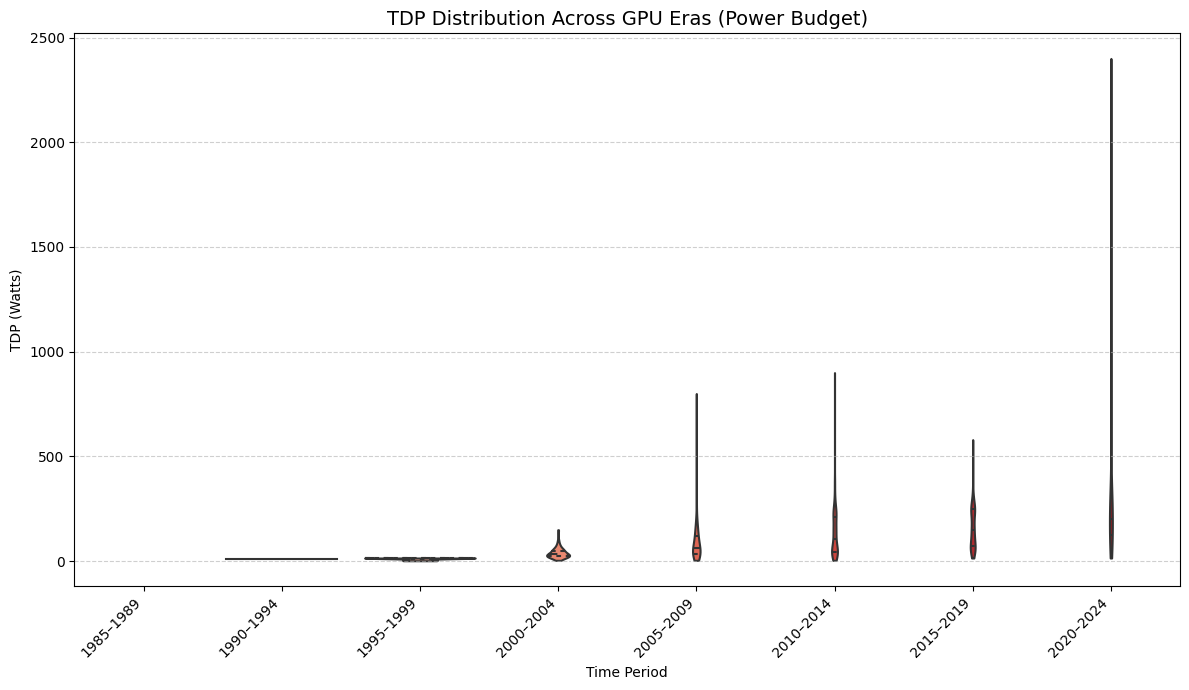

In [9]:
df_tdp = df_cleaned.dropna(subset=['Board Design_CLEAN_TDP']).copy()
df_tdp['TDP_Bin'] = pd.cut(
    df_tdp['Release_Year'], 
    bins=np.arange(1985, 2030, 5), 
    labels=[f'{i}–{i+4}' for i in np.arange(1985, 2025, 5)], 
    right=False
)

plt.figure(figsize=(12, 7))
sns.violinplot(
    x='TDP_Bin', 
    y='Board Design_CLEAN_TDP', 
    data=df_tdp, 
    palette='Reds', 
    inner='quartile', 
    cut=0
)

plt.title('TDP Distribution Across GPU Eras (Power Budget)', fontsize=14)
plt.xlabel('Time Period')
plt.ylabel('TDP (Watts)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

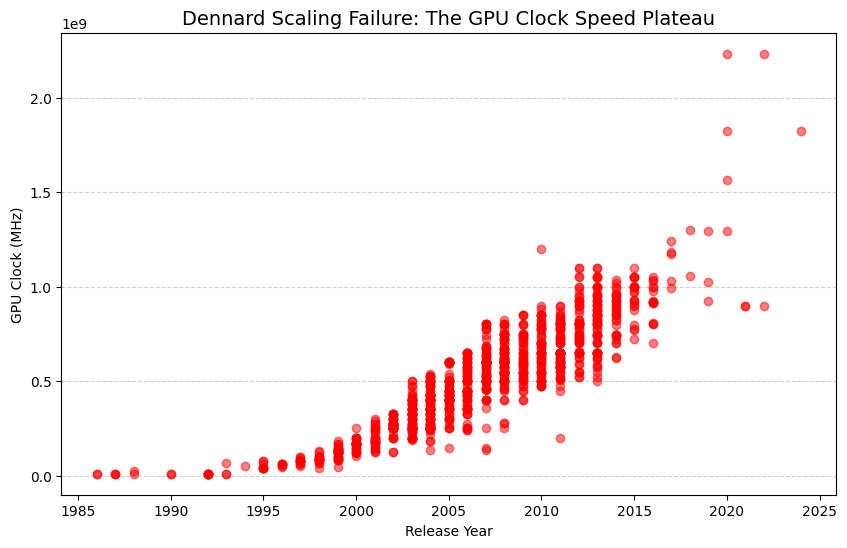

In [10]:

plt.figure(figsize=(10, 6))
df_dennard = df_cleaned.dropna(subset=['GPU_Clock']).sort_values('Release_Year')


plt.plot(df_dennard['Release_Year'], df_dennard['GPU_Clock'], marker='o', linestyle='', alpha=0.5, color='red')
plt.title('Dennard Scaling Failure: The GPU Clock Speed Plateau', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('GPU Clock (MHz)')
plt.grid(True, axis='y', ls="--", alpha=0.6)
plt.show()